In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage



from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('../datasets/store_customers.csv')
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
5,1005,M,33.0,36.7,73.0
6,1006,F,48.0,90.4,34.0
7,1007,F,41.0,74.8,35.0
8,1008,F,31.0,42.3,43.0
9,1009,M,39.0,48.6,61.0


In [3]:
df.shape

(1000, 5)

In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    str    
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 39.2 KB


In [6]:
df.isna().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [9]:
df.shape

(982, 5)

In [10]:
df = df.drop(columns=['CustomerID'])

In [11]:
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['Gender'])

In [12]:
df.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100),gender_encoded
0,M,39.0,59.9,58.0,1
1,M,34.0,48.4,37.0,1
2,F,40.0,70.5,26.0,0
3,F,47.0,81.1,30.0,0
4,F,33.0,42.1,58.0,0
5,M,33.0,36.7,73.0,1
6,F,48.0,90.4,34.0,0
7,F,41.0,74.8,35.0,0
8,F,31.0,42.3,43.0,0
9,M,39.0,48.6,61.0,1


In [13]:
df.gender_encoded.value_counts()

gender_encoded
0    511
1    471
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

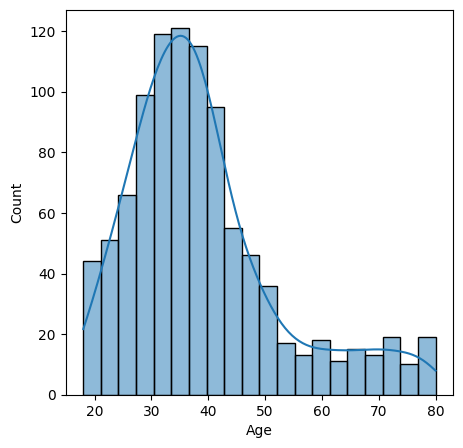

In [14]:
plt.figure(figsize=(5,5))

sns.histplot(
    x=df['Age'],
    bins=20,
    kde=True,
    data = df
)

<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

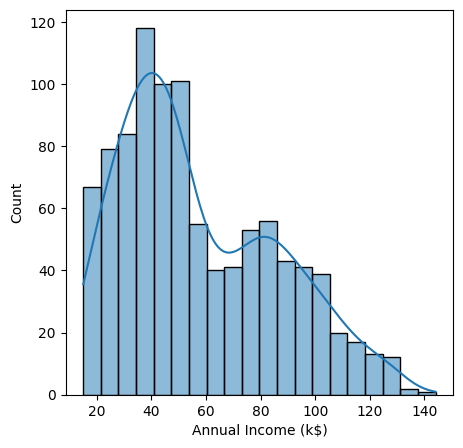

In [15]:
plt.figure(figsize=(5,5))

sns.histplot(
    x=df['Annual Income (k$)'],
    bins=20,
    kde=True,
    data = df
)

<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

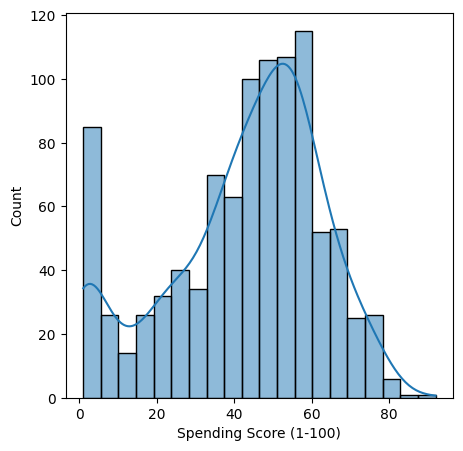

In [60]:
plt.figure(figsize=(5,5))

sns.histplot(
    x=df['Spending Score (1-100)'],
    bins=20,
    kde=True,
    data = df
)

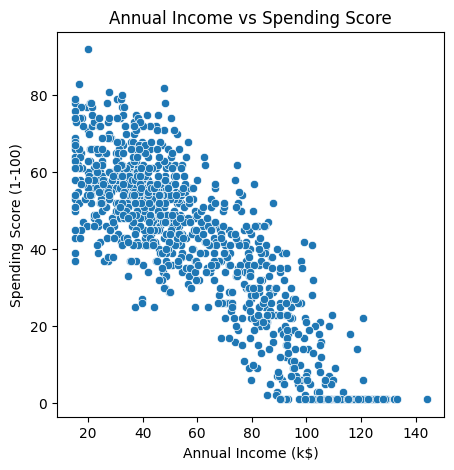

In [17]:
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)'
)

plt.title('Annual Income vs Spending Score')
plt.show()

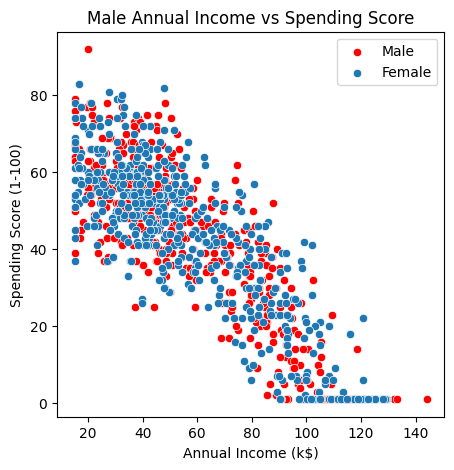

In [18]:
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=df[df['gender_encoded']==1],
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    label = 'Male',
    color = 'red'
)

sns.scatterplot(
    data=df[df['gender_encoded']==0],
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    label = 'Female'
)

plt.title('Male Annual Income vs Spending Score')
plt.show()

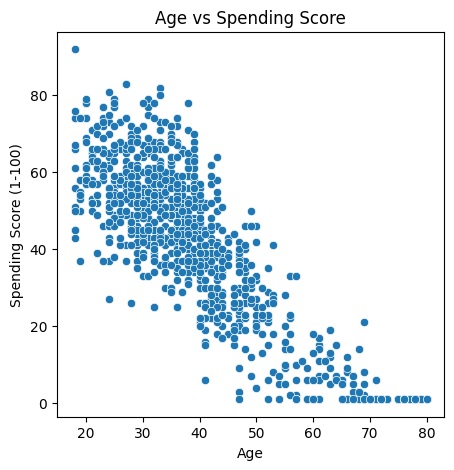

In [19]:
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)'
)

plt.title('Age vs Spending Score')
plt.show()

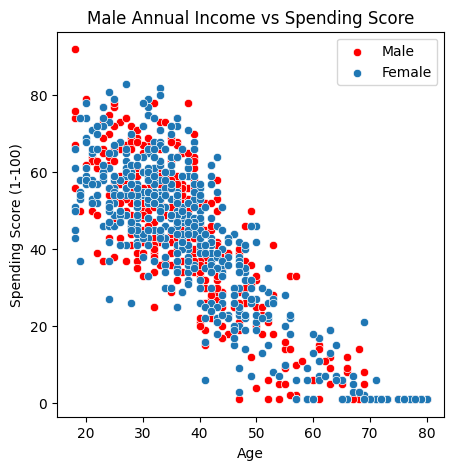

In [20]:
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=df[df['gender_encoded']==1],
    x='Age',
    y='Spending Score (1-100)',
    label = 'Male',
    color = 'red'
)

sns.scatterplot(
    data=df[df['gender_encoded']==0],
    x='Age',
    y='Spending Score (1-100)',
    label = 'Female'
)

plt.title('Male Annual Income vs Spending Score')
plt.show()

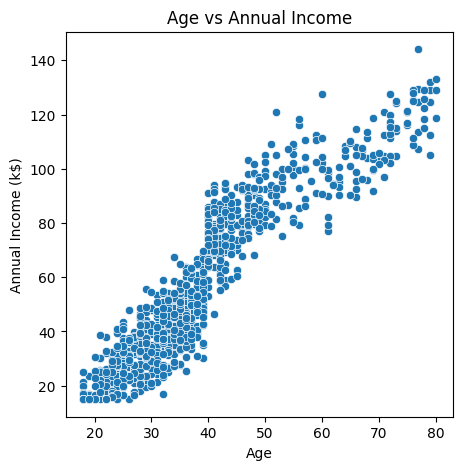

In [21]:
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Annual Income (k$)'
)

plt.title('Age vs Annual Income')
plt.show()

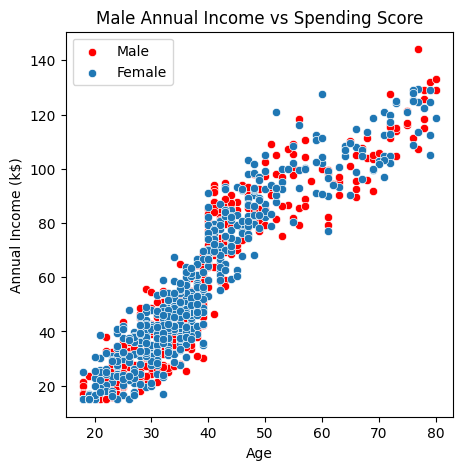

In [22]:
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=df[df['gender_encoded']==1],
    x='Age',
    y='Annual Income (k$)',
    label = 'Male',
    color = 'red'
)

sns.scatterplot(
    data=df[df['gender_encoded']==0],
    x='Age',
    y='Annual Income (k$)',
    label = 'Female'
)

plt.title('Male Annual Income vs Spending Score')
plt.show()

<Axes: ylabel='Age'>

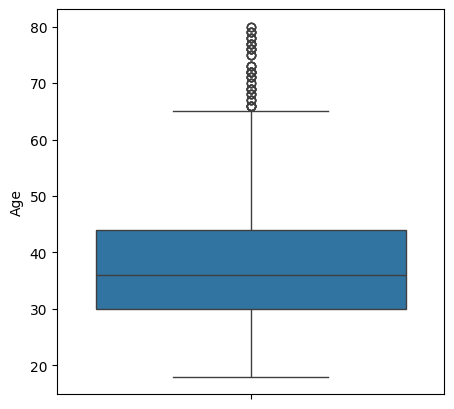

In [23]:
plt.figure(figsize=(5,5))

sns.boxplot(
    y='Age',
    data=df
)

<Axes: ylabel='Age'>

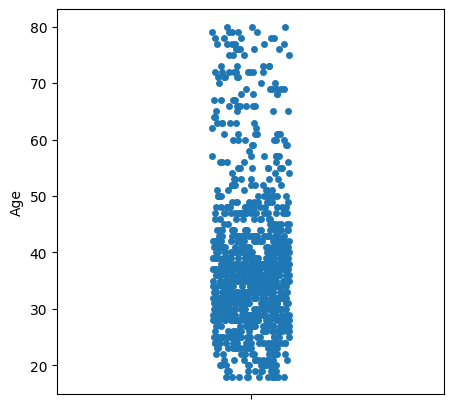

In [24]:
plt.figure(figsize=(5,5))

sns.stripplot(
    y='Age',
    data=df
)

<Axes: ylabel='Annual Income (k$)'>

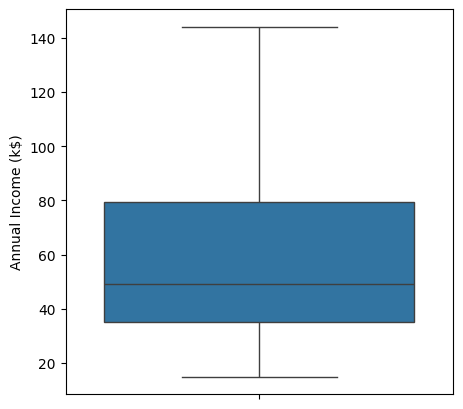

In [25]:
plt.figure(figsize=(5,5))

sns.boxplot(
    y='Annual Income (k$)',
    data=df
)

<Axes: ylabel='Annual Income (k$)'>

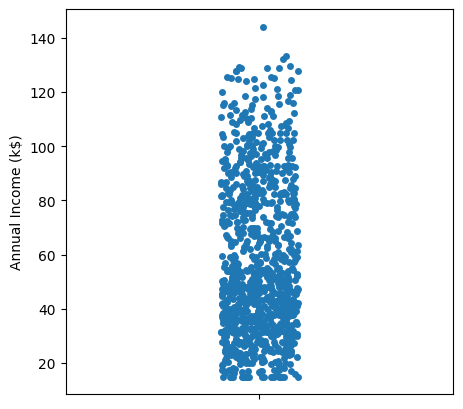

In [26]:
plt.figure(figsize=(5,5))

sns.stripplot(
    y='Annual Income (k$)',
    data=df
)

<Axes: ylabel='Spending Score (1-100)'>

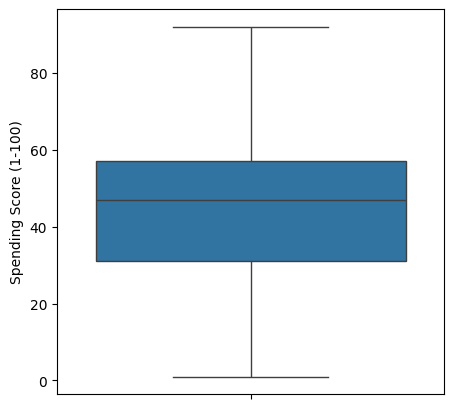

In [27]:
plt.figure(figsize=(5,5))

sns.boxplot(
    y='Spending Score (1-100)',
    data=df
)

<Axes: ylabel='Spending Score (1-100)'>

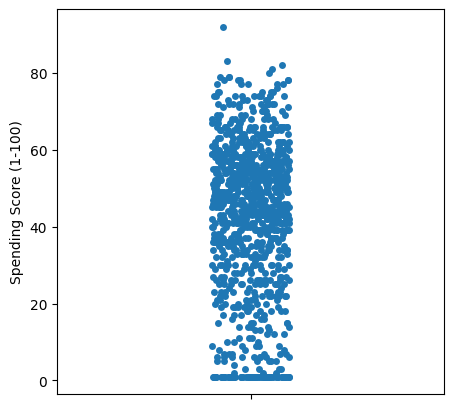

In [28]:
plt.figure(figsize=(5,5))

sns.stripplot(
    y='Spending Score (1-100)',
    data=df
)

In [61]:
df.shape

(982, 5)

In [29]:
df_test = df[(df['Spending Score (1-100)']>3) & (df['Spending Score (1-100)']<80)]
df_test = df_test[(df_test['Annual Income (k$)']<140)]

In [30]:
df_test.shape

(899, 5)

In [31]:
def clean_dataset(columns):
    for attribute in columns:
        q1 = df_test[attribute].quantile(0.25)
        q3 = df_test[attribute].quantile(0.75)
        
        iqr = q3-q1
        
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        df_clean = df_test[
            (df_test[attribute] >= lower_bound) &
            (df_test[attribute] <= upper_bound)
        ]
    return df_clean

columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
df_clean = clean_dataset(columns)

In [32]:
df_clean.shape

(898, 5)

In [33]:
df_clean.describe()

,Age,Annual Income (k$),Spending Score (1-100),gender_encoded
count,898.000000,898.000000,898.000000,898.000000
mean,36.299555,52.639310,46.020045,0.483296
std,9.924263,24.311125,16.445635,0.499999
min,18.000000,15.000000,5.000000,0.000000
25%,29.000000,34.125000,36.000000,0.000000
50%,36.000000,47.500000,48.000000,0.000000
75%,41.000000,71.900000,57.000000,1.000000
max,71.000000,120.900000,79.000000,1.000000


<Axes: ylabel='Spending Score (1-100)'>

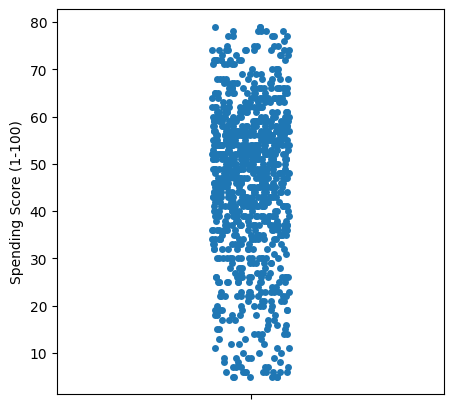

In [34]:
plt.figure(figsize=(5,5))

sns.stripplot(
    y='Spending Score (1-100)',
    data=df_clean
)

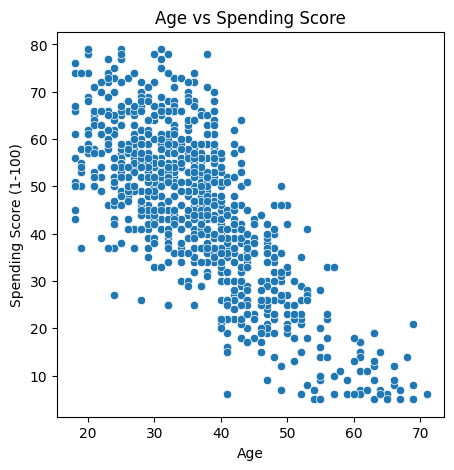

In [35]:
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=df_clean,
    x='Age',
    y='Spending Score (1-100)'
)

plt.title('Age vs Spending Score')
plt.show()

In [36]:
X = df_clean[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [37]:
X.shape

(898, 3)

In [38]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[ 0.27225703,  0.29882354,  0.72886401],
       [-0.23183949, -0.17447452, -0.54878216],
       [ 0.37307633,  0.73508089, -1.21802539],
       ...,
       [ 0.77635354,  1.23307278, -0.36626128],
       [ 0.97799215,  0.6198431 , -1.21802539],
       [-0.83675531, -0.28559668,  0.7897043 ]], shape=(898, 3))

In [39]:
X_scaled_df = pd.DataFrame(X_scaled, columns=['Age','Annual Income (k$)','Spending Score (1-100)'])

In [40]:
wcss = []

K=range(1,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


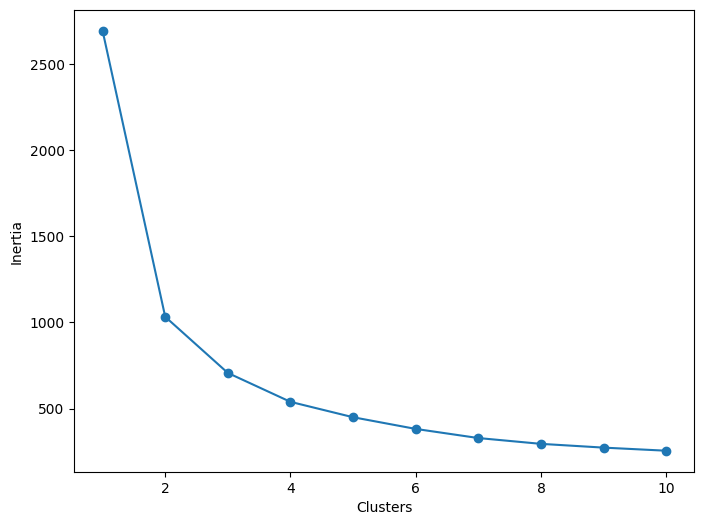

In [41]:
plt.figure(figsize=(8,6))
plt.plot(K, wcss, marker='o')
plt.xlabel('Clusters')
plt.ylabel('Inertia')
plt.show()

In [42]:
sil_scores = []

K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k,random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

sil_scores

[0.5310674845664097,
 0.3755269494887543,
 0.3518896494685084,
 0.31694575128088515,
 0.31572976091620775,
 0.31467499863643733,
 0.31034413433861885,
 0.29916529538417397,
 0.28004654234214643]

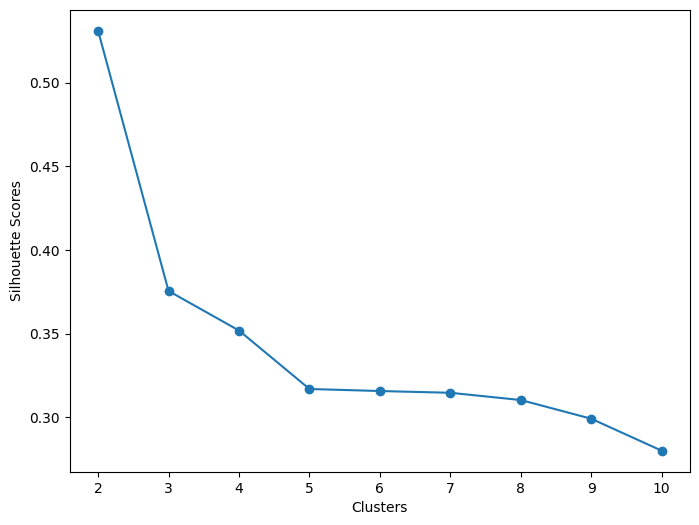

In [43]:
plt.figure(figsize=(8,6))
plt.plot(K, sil_scores, marker='o')
plt.xlabel('Clusters')
plt.ylabel('Silhouette Scores')
plt.show()

In [44]:
X_scaled.shape

(898, 3)

In [45]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10, init='random')
labels_kmeans = kmeans.fit_predict(X_scaled)

In [46]:
labels_kmeans

array([3, 3, 2, 2, 3, 0, 2, 2, 3, 3, 0, 0, 3, 0, 0, 0, 0, 3, 0, 0, 2, 3,
       3, 0, 0, 3, 3, 3, 3, 0, 2, 3, 0, 3, 0, 3, 0, 0, 3, 2, 3, 3, 3, 0,
       3, 0, 3, 3, 0, 3, 3, 3, 2, 2, 2, 0, 3, 3, 2, 0, 3, 0, 0, 2, 2, 3,
       3, 0, 3, 0, 2, 0, 3, 3, 3, 0, 0, 3, 3, 2, 3, 3, 0, 2, 3, 0, 3, 3,
       2, 0, 0, 3, 0, 3, 3, 3, 3, 0, 0, 3, 3, 1, 3, 3, 3, 0, 3, 3, 1, 3,
       3, 3, 2, 2, 2, 0, 2, 0, 2, 1, 0, 0, 3, 0, 0, 3, 0, 3, 2, 3, 3, 2,
       0, 3, 2, 0, 2, 3, 2, 0, 3, 2, 3, 3, 3, 0, 3, 3, 0, 2, 3, 0, 2, 0,
       2, 2, 0, 2, 3, 2, 1, 3, 0, 0, 0, 3, 3, 3, 2, 3, 2, 0, 2, 0, 0, 3,
       0, 2, 3, 3, 0, 3, 2, 3, 0, 2, 3, 0, 0, 3, 0, 3, 3, 2, 2, 0, 0, 3,
       3, 3, 2, 2, 3, 3, 3, 2, 0, 3, 3, 3, 1, 0, 3, 0, 3, 2, 3, 0, 3, 2,
       0, 3, 3, 0, 1, 3, 0, 0, 0, 2, 3, 3, 2, 2, 0, 3, 0, 0, 2, 2, 0, 2,
       1, 2, 0, 3, 2, 0, 3, 2, 0, 0, 0, 0, 3, 0, 2, 0, 0, 3, 2, 0, 2, 0,
       3, 2, 3, 0, 3, 3, 3, 2, 2, 0, 2, 3, 2, 3, 3, 0, 3, 3, 2, 3, 0, 2,
       3, 2, 2, 3, 3, 2, 2, 3, 3, 2, 0, 3, 3, 3, 2,

In [47]:
np.unique(labels_kmeans)

array([0, 1, 2, 3], dtype=int32)

In [48]:
X["KMeans_Cluster"] = labels_kmeans
X.head()

,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,39.0,59.9,58.0,3
1,34.0,48.4,37.0,3
2,40.0,70.5,26.0,2
3,47.0,81.1,30.0,2
4,33.0,42.1,58.0,3


In [49]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers

array([[26.65949821, 28.44623656, 60.3297491 ],
       [57.51898734, 96.77468354, 14.02531646],
       [43.52475248, 78.0519802 , 33.47524752],
       [34.97928994, 47.10621302, 49.18343195]])

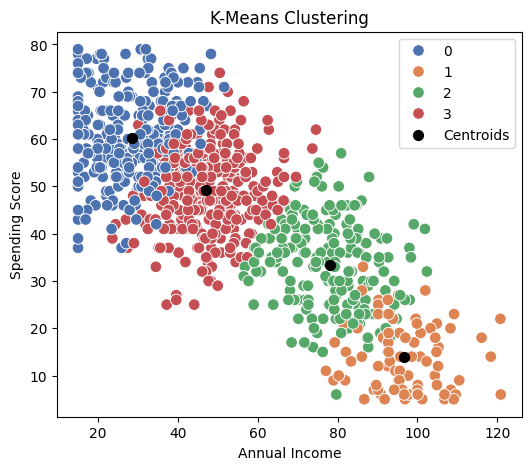

In [50]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x=X['Annual Income (k$)'],
    y=X['Spending Score (1-100)'],
    hue=labels_kmeans,
    palette='deep', 
    s=70
)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 1],      
    centers[:, 2],      
    s=50,
    marker='o',
    color='black',
    label='Centroids',
    zorder=1           
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

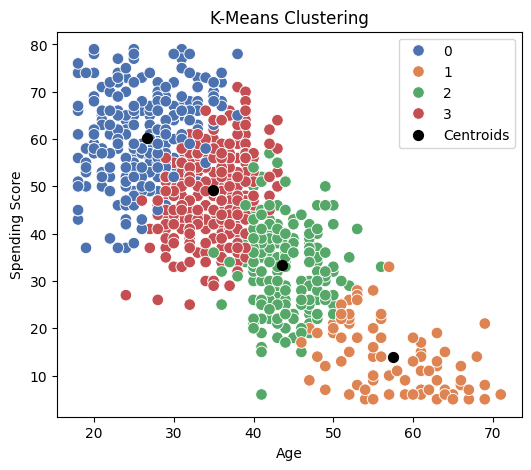

In [51]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x=X['Age'],
    y=X['Spending Score (1-100)'],
    hue=labels_kmeans,
    palette='deep', 
    s=70
)

centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 0],      
    centers[:, 2],      
    s=50,
    marker='o',
    color='black',
    label='Centroids',
    zorder=1           
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

In [52]:
linked = linkage(X_scaled, method='ward')

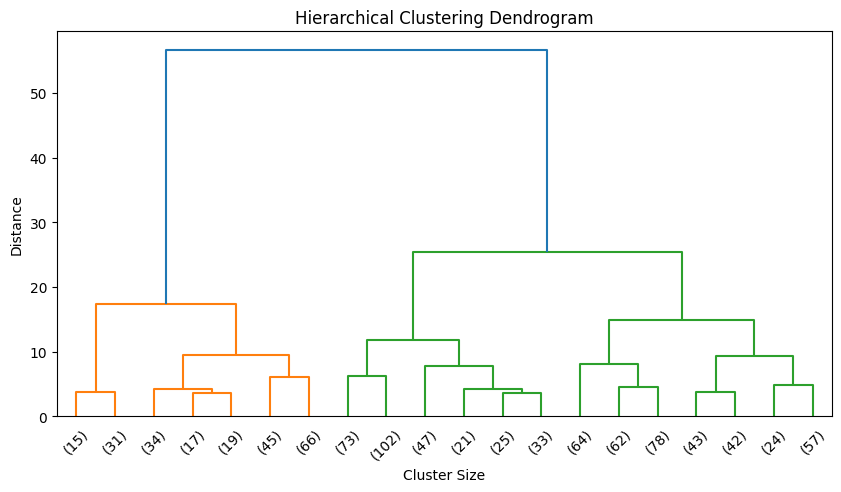

In [53]:
plt.figure(figsize=(10,5))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=45,
    leaf_font_size=10
)
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

In [54]:
hier = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

labels_hier = hier.fit_predict(X_scaled)

In [55]:
np.unique(labels_hier)

array([0, 1, 2, 3])

In [56]:
X["Hierarchical_Cluster"] = labels_hier

In [57]:
X.head(10)

,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,Hierarchical_Cluster
0,39.0,59.9,58.0,3,0
1,34.0,48.4,37.0,3,0
2,40.0,70.5,26.0,2,1
3,47.0,81.1,30.0,2,1
4,33.0,42.1,58.0,3,0
5,33.0,36.7,73.0,0,0
6,48.0,90.4,34.0,2,1
7,41.0,74.8,35.0,2,1
8,31.0,42.3,43.0,3,0
9,39.0,48.6,61.0,3,0


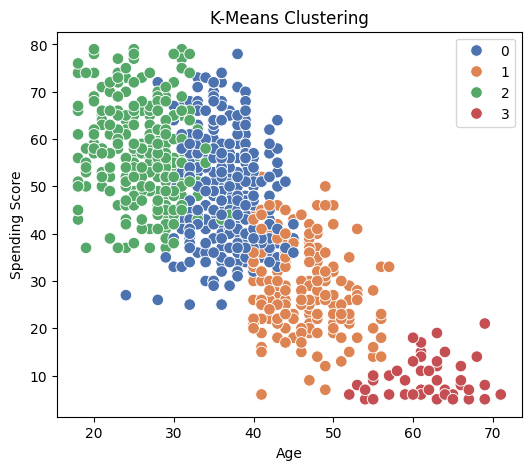

In [58]:
plt.figure(figsize=(6,5))

sns.scatterplot(
    x=X['Age'],
    y=X['Spending Score (1-100)'],
    hue=labels_hier,
    palette='deep', 
    s=70
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.legend()
plt.show()